<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

fatal: destination path 'AI-Course' already exists and is not an empty directory.
/content/AI-Course
 AICourse.ipynb      Assignment5.ipynb	 Assignment9.ipynb	     images.zip
 assignment2.ipynb   Assignment6.ipynb	 git_github_exercise.ipynb   README.md
 Assignment3.ipynb   Assignment7.ipynb	 images
 Assignment4.ipynb   Assignment8.ipynb	'images (1).zip'


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	images (1).zip
	images.zip
	images/

nothing added to commit but untracked files present (use "git add" to track)


In [4]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC

In [5]:
# Extract and load images
!unzip images.zip

data_dir = "images"

images = []
labels = []

## Folder structure
#images/
#     dalmatian/
#     dollar_bill/
#     pizza/
#     soccer_ball/
#     sunflower/

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)

    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)

            try:
                img = cv2.imread(img_path)
                img = cv2.resize(img, (64, 64))

                img = img / 255.0 # normalize

                images.append(img)
                labels.append(label)

            except:
                continue

## Convert to numpy
X = np.array(images)
y = np.array(labels)

print("Dataset shape:", X.shape)

Archive:  images.zip
  inflating: images/dalmatian/image_0001.jpg  
  inflating: images/dalmatian/image_0002.jpg  
  inflating: images/dalmatian/image_0003.jpg  
  inflating: images/dalmatian/image_0004.jpg  
  inflating: images/dalmatian/image_0005.jpg  
  inflating: images/dalmatian/image_0006.jpg  
  inflating: images/dalmatian/image_0007.jpg  
  inflating: images/dalmatian/image_0008.jpg  
  inflating: images/dalmatian/image_0009.jpg  
  inflating: images/dalmatian/image_0010.jpg  
  inflating: images/dalmatian/image_0011.jpg  
  inflating: images/dalmatian/image_0012.jpg  
  inflating: images/dalmatian/image_0013.jpg  
  inflating: images/dalmatian/image_0014.jpg  
  inflating: images/dalmatian/image_0015.jpg  
  inflating: images/dalmatian/image_0016.jpg  
  inflating: images/dalmatian/image_0017.jpg  
  inflating: images/dalmatian/image_0018.jpg  
  inflating: images/dalmatian/image_0019.jpg  
  inflating: images/dalmatian/image_0020.jpg  
  inflating: images/dalmatian/image_002

In [6]:
# Flatten images
X = X.reshape(X.shape[0], -1)

In [7]:
# Train - Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# Model creation and training
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best Score: 0.7447840141052012



Classification Report:

              precision    recall  f1-score   support

   dalmatian       0.50      0.73      0.59        11
 dollar_bill       0.86      0.60      0.71        10
       pizza       0.78      0.64      0.70        11
 soccer_ball       0.45      0.38      0.42        13
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.66        62
   macro avg       0.68      0.65      0.65        62
weighted avg       0.68      0.66      0.66        62



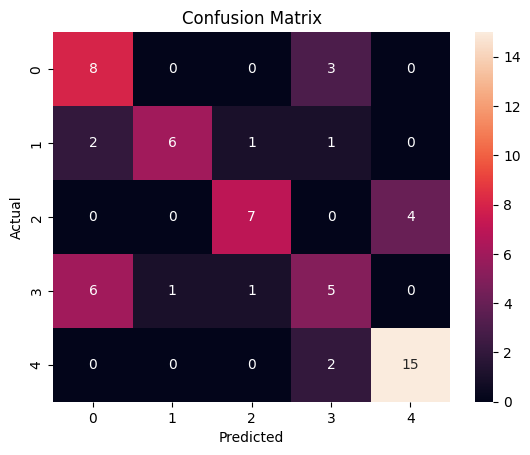

In [9]:
# Model evaluation
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

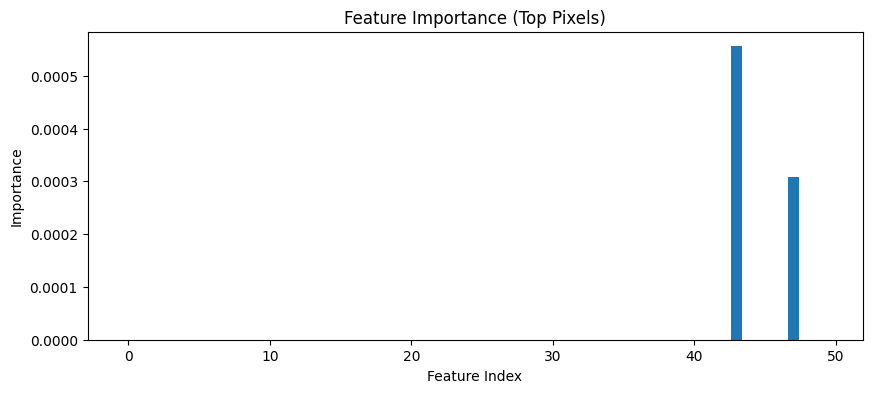

In [11]:
# Feature Importance
importances = best_model.feature_importances_

plt.figure(figsize=(10,4))
plt.bar(range(50), importances[:50])
plt.title("Feature Importance (Top Pixels)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

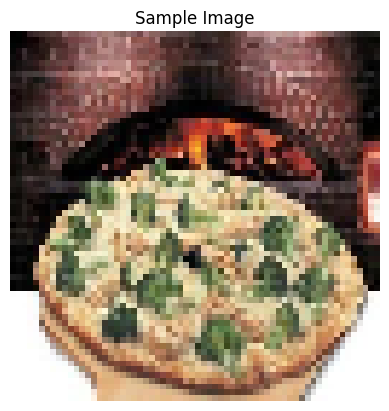

Predicted class: pizza


In [13]:
# Predicting New Image
sample_img = images[0]

img_display = (sample_img * 255).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
plt.title("Sample Image")
plt.axis("off")
plt.show()

# Preprocessing
sample = sample_img.reshape(1, -1)

# Prediction
prediction = best_model.predict(sample)

print("Predicted class:", prediction[0])

In [14]:
# Bonus: Comparing with SVM
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("\nSVM Results:\n")
print(classification_report(y_test, svm_pred))


SVM Results:

              precision    recall  f1-score   support

   dalmatian       0.53      0.73      0.62        11
 dollar_bill       0.83      0.50      0.62        10
       pizza       0.89      0.73      0.80        11
 soccer_ball       0.62      0.62      0.62        13
   sunflower       0.89      1.00      0.94        17

    accuracy                           0.74        62
   macro avg       0.75      0.71      0.72        62
weighted avg       0.76      0.74      0.74        62



In [16]:
import os

notebook_filename = "Assignment11.ipynb"

# Check if the notebook file exists. If not, create a placeholder.
if not os.path.exists(notebook_filename):
    # This assumes the user intended to save the current notebook as Assignment11.ipynb
    # but hasn't done so yet via the Colab UI. We create a placeholder so 'git add' doesn't fail.
    with open(notebook_filename, 'w') as f:
        f.write("# This is a placeholder for Assignment 11.\n")
        f.write("# Please save your actual notebook content to this file via Colab's 'File -> Save a copy as...' option.\n")
    print(f"Created a placeholder file '{notebook_filename}'.")
    print("WARNING: You might need to manually save your current notebook content as this file for your actual changes to be committed.")
else:
    print(f"File '{notebook_filename}' already exists.")

# Now proceed with git add and commit
!git add {notebook_filename}
!git commit -m "Add Assignment 11"

Created a placeholder file 'Assignment11.ipynb'.
[main d19a196] Add Assignment 11
 1 file changed, 2 insertions(+)
 create mode 100644 Assignment11.ipynb
